# Yield Curve Decoded

PCA decomposition of the US Treasury yield curve and recession prediction from curve shape features.

**Data:** FRED API - 8 Treasury constant maturity series (1M through 30Y) + NBER recession indicator, daily from 1976 to present.

**Methods:** Principal Component Analysis (level, slope, curvature) + XGBoost recession classifier with SHAP interpretability.

In [1]:
import pandas as pd
import numpy as np
import requests
import os
import time
from datetime import datetime, timedelta
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.model_selection import ParameterSampler
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 30)

In [2]:
C = {
    "primary":    "#1e293b",
    "secondary":  "#334155",
    "accent":     "#2563eb",
    "risk":       "#dc2626",
    "safe":       "#059669",
    "warn":       "#d97706",
    "recession":  "#fee2e2",
    "light_gray": "#f1f5f9",
    "mid_gray":   "#94a3b8",
    "dark_gray":  "#475569",
}

plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#e2e8f0",
    "axes.labelcolor": C["primary"],
    "axes.titlecolor": C["primary"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.color": "#f1f5f9",
    "grid.linewidth": 0.8,
    "xtick.color": C["dark_gray"],
    "ytick.color": C["dark_gray"],
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial"],
    "figure.dpi": 100,
    "legend.frameon": False,
    "legend.fontsize": 9,
})

def style_axis(ax, title="", subtitle="", xlabel="", ylabel=""):
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=C["primary"], pad=12, loc="left")
    if subtitle:
        ax.text(0, 1.06, subtitle, transform=ax.transAxes, fontsize=10,
                color=C["dark_gray"], style="italic", va="bottom")
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=C["secondary"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=C["secondary"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#e2e8f0")
    ax.spines["bottom"].set_color("#e2e8f0")
    return ax

def shade_recessions(ax, recessions_series):
    """Add light red shading for NBER recession periods."""
    in_recession = False
    start = None
    for date, val in recessions_series.items():
        if val == 1 and not in_recession:
            start = date
            in_recession = True
        elif val == 0 and in_recession:
            ax.axvspan(start, date, alpha=0.15, color=C["risk"], zorder=0)
            in_recession = False
    if in_recession:
        ax.axvspan(start, recessions_series.index[-1], alpha=0.15, color=C["risk"], zorder=0)

def fmt_k(x, _=None):
    if abs(x) >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

print("Style configured.")

Style configured.


In [3]:
FRED_API_KEY = os.environ.get("FRED_API_KEY", "PASTE_YOUR_KEY_HERE")
FRED_BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

def fetch_fred(series_id, start_date="1976-01-01", max_retries=3):
    """Fetch a FRED series and return as pd.Series indexed by date."""
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start_date,
    }
    for attempt in range(max_retries):
        try:
            resp = requests.get(FRED_BASE_URL, params=params, timeout=30)
            if resp.status_code == 429:
                time.sleep(2 ** attempt)
                continue
            resp.raise_for_status()
            data = resp.json()
            break
        except requests.exceptions.RequestException as exc:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
                continue
            raise RuntimeError(f"Failed to fetch {series_id}: {exc}")

    df = pd.DataFrame(data["observations"])
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    s = df.set_index("date")["value"].dropna()
    s.name = series_id
    return s

print("FRED fetcher ready.")

FRED fetcher ready.


In [4]:
YIELD_SERIES = {
    "3M":  "DGS3MO",
    "6M":  "DGS6MO",
    "1Y":  "DGS1",
    "2Y":  "DGS2",
    "5Y":  "DGS5",
    "10Y": "DGS10",
    "30Y": "DGS30",
}

MATURITY_ORDER = ["3M", "6M", "1Y", "2Y", "5Y", "10Y", "30Y"]
MATURITY_YEARS = [3/12, 6/12, 1, 2, 5, 10, 30]

print("Fetching Treasury yields...")
yields = {}
for label, sid in YIELD_SERIES.items():
    yields[label] = fetch_fred(sid)
    print(f"  {label} ({sid}): {len(yields[label]):,} obs")

curve_df = pd.DataFrame(yields).sort_index()
curve_df = curve_df.dropna()

print(f"\nFetching NBER recession indicator...")
recession = fetch_fred("USREC", start_date="1976-01-01")
recession_daily = recession.reindex(curve_df.index, method="ffill").fillna(0).astype(int)

print(f"\nYield curve matrix: {curve_df.shape[0]:,} days x {curve_df.shape[1]} maturities")
print(f"Date range: {curve_df.index.min():%Y-%m-%d} to {curve_df.index.max():%Y-%m-%d}")
print(f"Recession days: {recession_daily.sum():,} ({recession_daily.mean():.1%})")

Fetching Treasury yields...


  3M (DGS3MO): 11,180 obs


  6M (DGS6MO): 11,180 obs


  1Y (DGS1): 12,593 obs


  2Y (DGS2): 12,490 obs


  5Y (DGS5): 12,593 obs


  10Y (DGS10): 12,593 obs


  30Y (DGS30): 12,312 obs

Fetching NBER recession indicator...



Yield curve matrix: 11,180 days x 7 maturities
Date range: 1981-09-01 to 2026-05-21
Recession days: 1,056 (9.4%)


---
## Exploratory Data Analysis

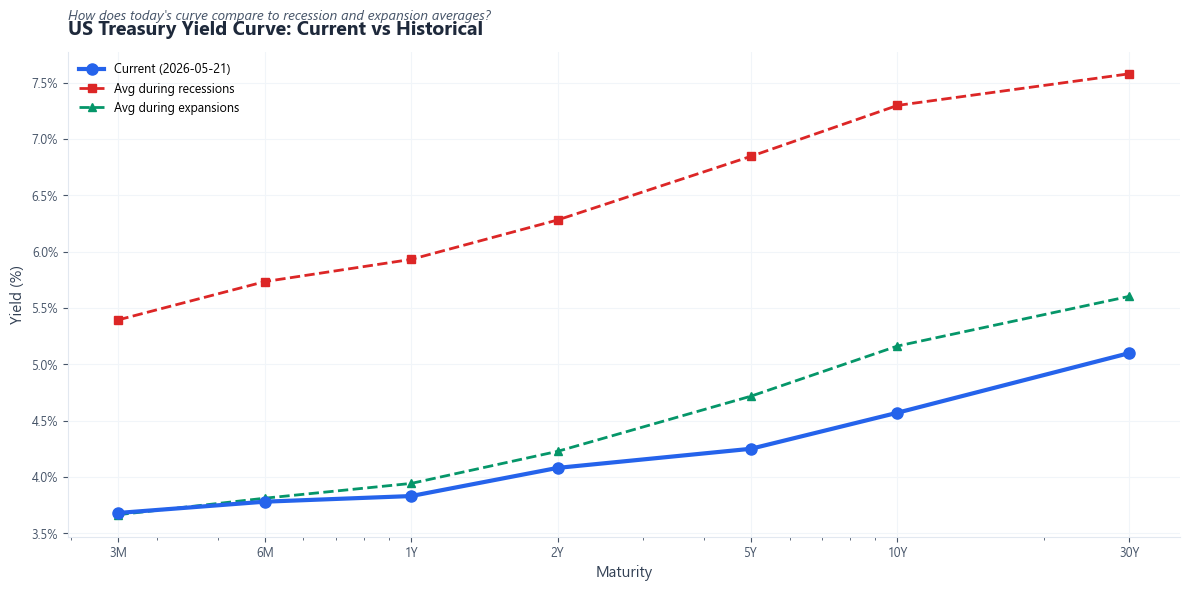

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

current = curve_df.iloc[-1]
ax.plot(MATURITY_YEARS, current.values, "o-", lw=3, color=C["accent"],
        markersize=8, label=f"Current ({curve_df.index[-1]:%Y-%m-%d})", zorder=5)

recession_mask = recession_daily.reindex(curve_df.index).fillna(0) == 1
if recession_mask.sum() > 0:
    recession_avg = curve_df[recession_mask].mean()
    ax.plot(MATURITY_YEARS, recession_avg.values, "s--", lw=2, color=C["risk"],
            markersize=6, label="Avg during recessions")

expansion_avg = curve_df[~recession_mask].mean()
ax.plot(MATURITY_YEARS, expansion_avg.values, "^--", lw=2, color=C["safe"],
        markersize=6, label="Avg during expansions")

ax.set_xscale("log")
ax.set_xticks(MATURITY_YEARS)
ax.set_xticklabels(MATURITY_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()
style_axis(ax, title="US Treasury Yield Curve: Current vs Historical",
           subtitle="How does today's curve compare to recession and expansion averages?",
           xlabel="Maturity", ylabel="Yield (%)")
plt.tight_layout()
plt.show()

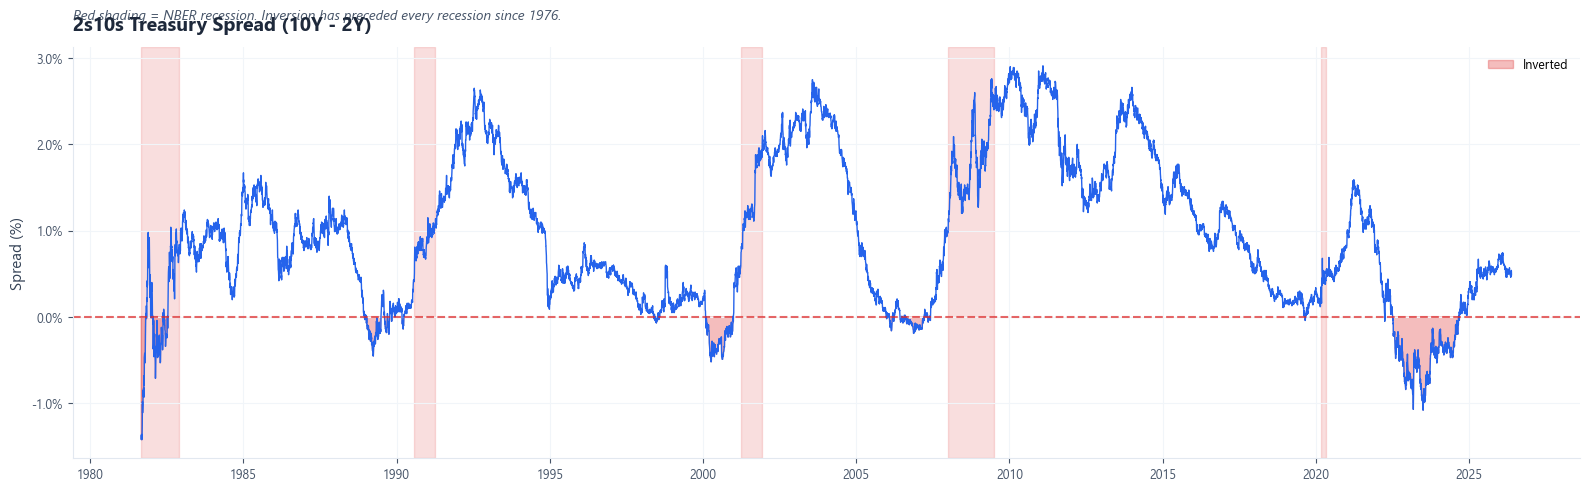

In [6]:
spread_2s10s = curve_df["10Y"] - curve_df["2Y"]

fig, ax = plt.subplots(figsize=(16, 5))
shade_recessions(ax, recession_daily)
ax.plot(spread_2s10s.index, spread_2s10s.values, lw=1, color=C["accent"])
ax.axhline(0, color=C["risk"], lw=1.5, ls="--", alpha=0.7)
ax.fill_between(spread_2s10s.index, spread_2s10s.values, 0,
                where=spread_2s10s < 0, alpha=0.3, color=C["risk"], label="Inverted")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()
style_axis(ax, title="2s10s Treasury Spread (10Y - 2Y)",
           subtitle="Red shading = NBER recession. Inversion has preceded every recession since 1976.",
           xlabel="", ylabel="Spread (%)")
plt.tight_layout()
plt.show()

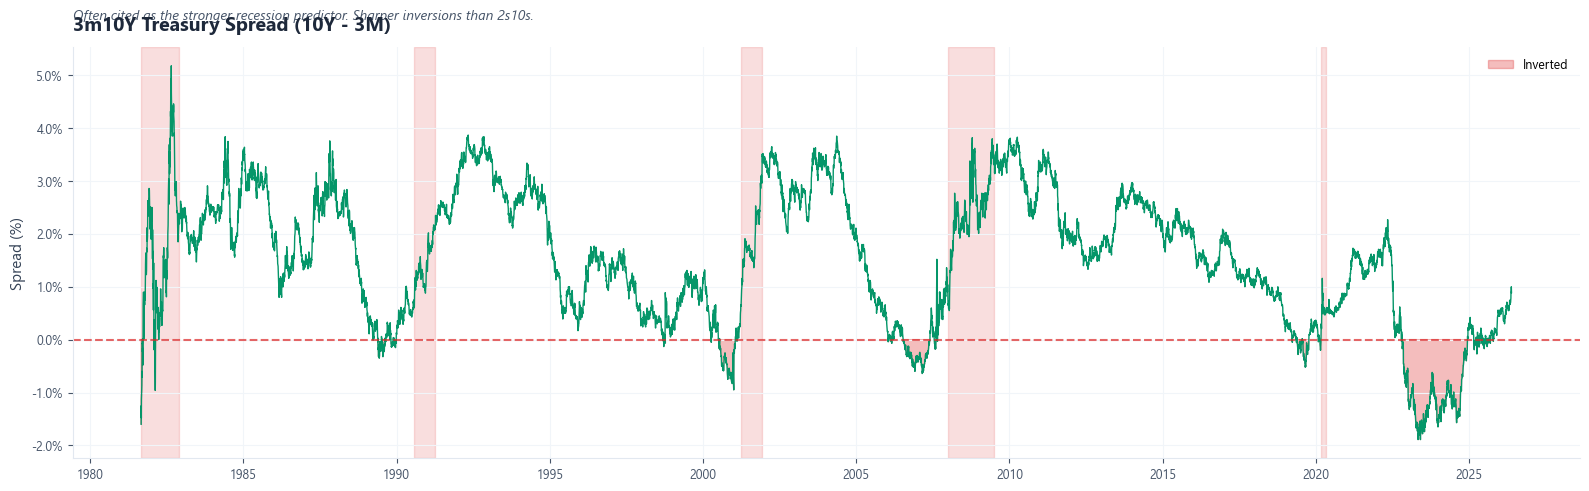

In [7]:
spread_3m10y = curve_df["10Y"] - curve_df["3M"]

fig, ax = plt.subplots(figsize=(16, 5))
shade_recessions(ax, recession_daily)
ax.plot(spread_3m10y.index, spread_3m10y.values, lw=1, color=C["safe"])
ax.axhline(0, color=C["risk"], lw=1.5, ls="--", alpha=0.7)
ax.fill_between(spread_3m10y.index, spread_3m10y.values, 0,
                where=spread_3m10y < 0, alpha=0.3, color=C["risk"], label="Inverted")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()
style_axis(ax, title="3m10Y Treasury Spread (10Y - 3M)",
           subtitle="Often cited as the stronger recession predictor. Sharper inversions than 2s10s.",
           xlabel="", ylabel="Spread (%)")
plt.tight_layout()
plt.show()

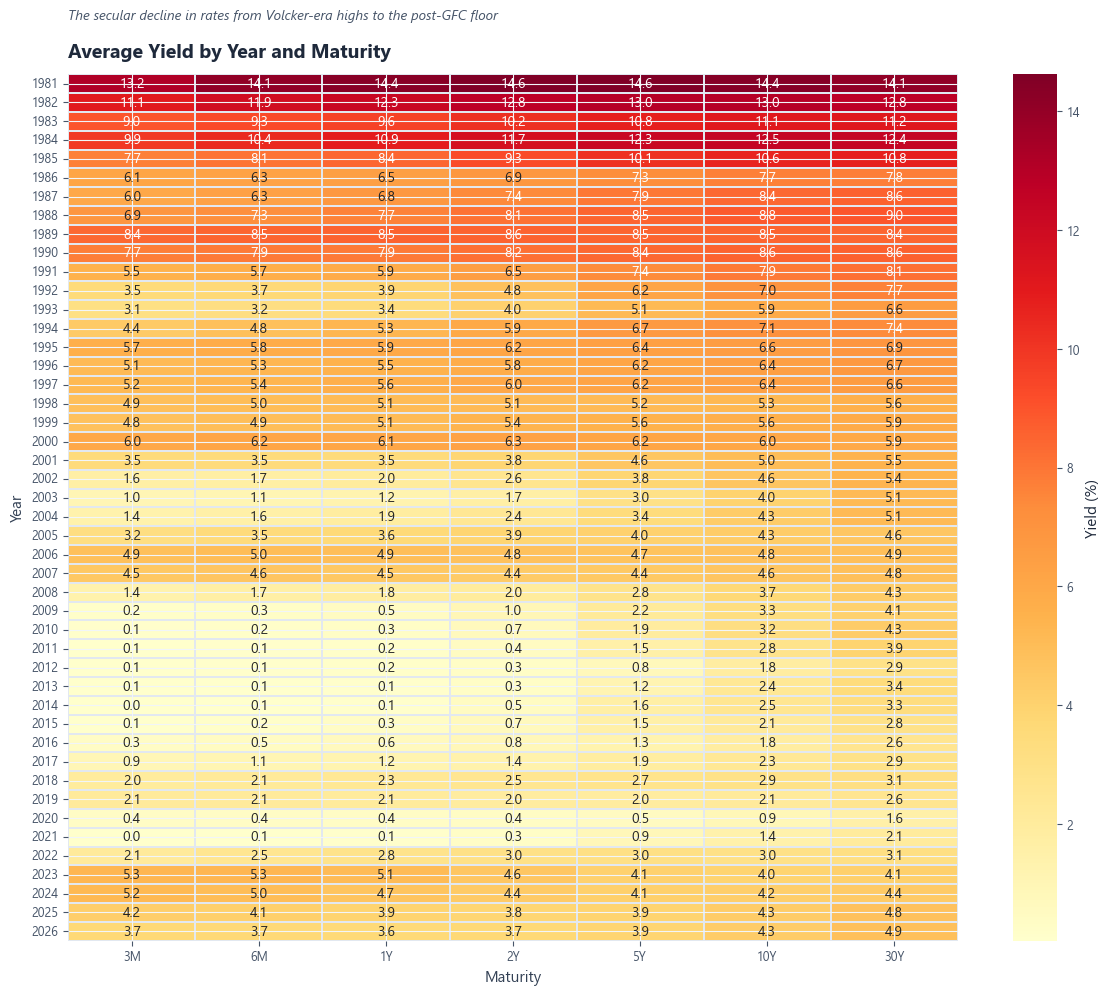

In [8]:
yearly_avg = curve_df.groupby(curve_df.index.year).mean()
yearly_avg = yearly_avg[MATURITY_ORDER]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(yearly_avg, cmap="YlOrRd", annot=True, fmt=".1f", ax=ax,
            linewidths=0.3, linecolor="#e2e8f0",
            cbar_kws={"label": "Yield (%)"})
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
style_axis(ax, title="Average Yield by Year and Maturity",
           subtitle="The secular decline in rates from Volcker-era highs to the post-GFC floor",
           xlabel="Maturity", ylabel="Year")
plt.tight_layout()
plt.show()

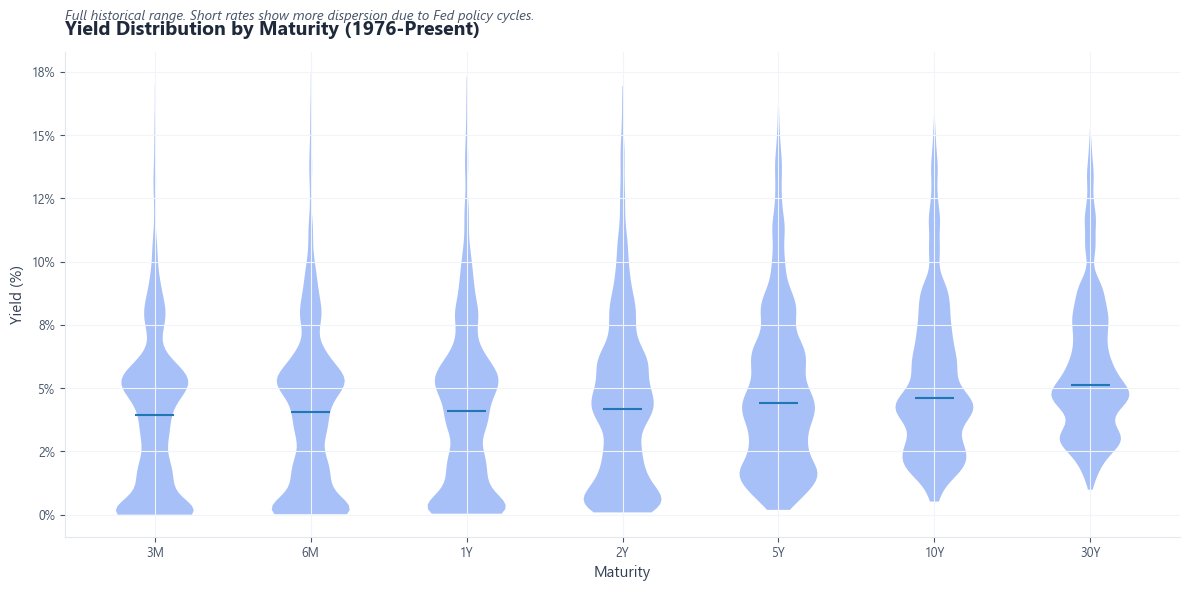

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
data_list = [curve_df[m].dropna().values for m in MATURITY_ORDER]
parts = ax.violinplot(data_list, positions=range(len(MATURITY_ORDER)), showmedians=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor(C["accent"])
    pc.set_alpha(0.4)
ax.set_xticks(range(len(MATURITY_ORDER)))
ax.set_xticklabels(MATURITY_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
style_axis(ax, title="Yield Distribution by Maturity (1976-Present)",
           subtitle="Full historical range. Short rates show more dispersion due to Fed policy cycles.",
           xlabel="Maturity", ylabel="Yield (%)")
plt.tight_layout()
plt.show()

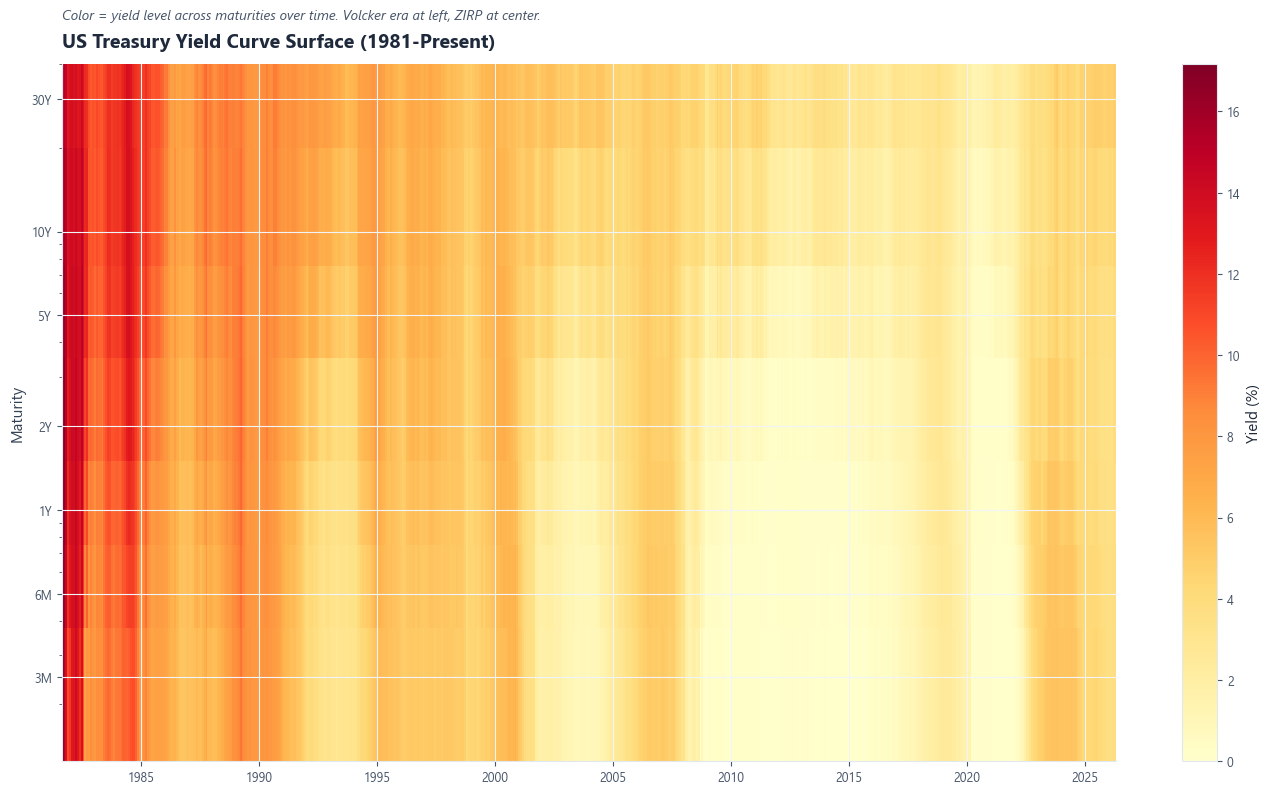

In [10]:
curve_sampled = curve_df.iloc[::20]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.pcolormesh(
    curve_sampled.index,
    MATURITY_YEARS,
    curve_sampled[MATURITY_ORDER].values.T,
    cmap="YlOrRd",
    shading="nearest",
)
ax.set_yscale("log")
ax.set_yticks(MATURITY_YEARS)
ax.set_yticklabels(MATURITY_ORDER)
cbar = plt.colorbar(im, ax=ax, label="Yield (%)")
style_axis(ax, title="US Treasury Yield Curve Surface (1981-Present)",
           subtitle="Color = yield level across maturities over time. Volcker era at left, ZIRP at center.",
           xlabel="", ylabel="Maturity")
plt.tight_layout()
plt.show()

---
## PCA Decomposition

The yield curve has three well-known latent factors: level (parallel shifts), slope (steepening/flattening), and curvature (belly moves). PCA recovers these empirically and quantifies how much of daily yield variation each factor explains.

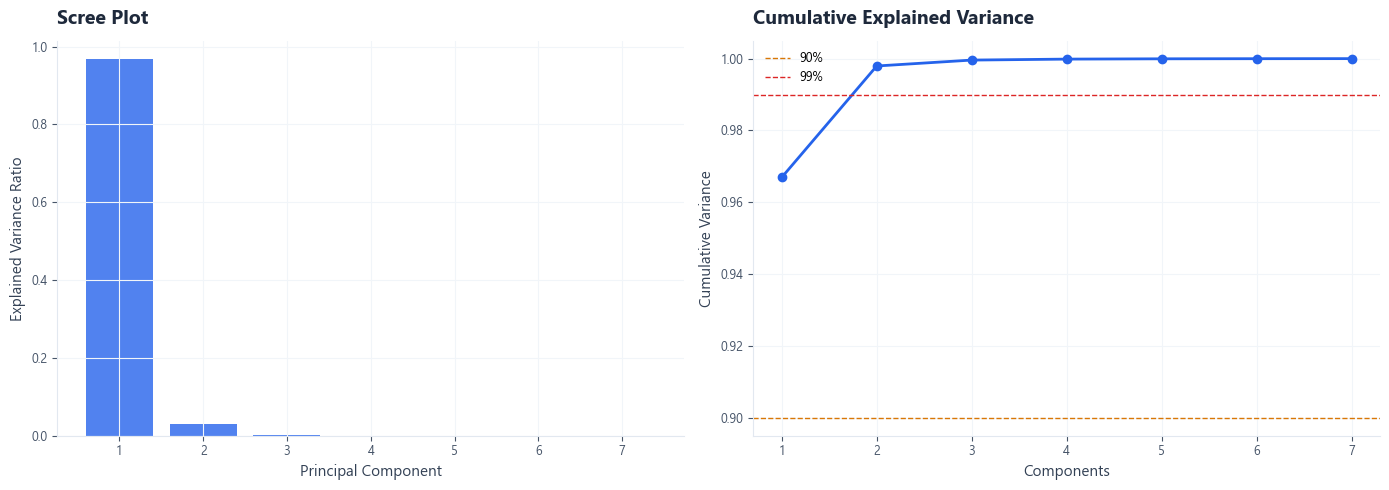

Explained variance by component:
  PC1: 0.9669 (96.7%)
  PC2: 0.0310 (3.1%)
  PC3: 0.0016 (0.2%)
  PC4: 0.0003 (0.0%)
  PC5: 0.0001 (0.0%)
  PC6: 0.0000 (0.0%)
  PC7: 0.0000 (0.0%)

First 3 components explain 100.0% of total yield curve variation.


In [11]:
scaler = StandardScaler()
curve_scaled = scaler.fit_transform(curve_df)

pca = PCA()
pca_scores = pca.fit_transform(curve_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_,
       color=C["accent"], alpha=0.8)
ax.set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))
style_axis(ax, title="Scree Plot", xlabel="Principal Component", ylabel="Explained Variance Ratio")

ax = axes[1]
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", color=C["accent"], lw=2)
ax.axhline(0.90, ls="--", color=C["warn"], lw=1, label="90%")
ax.axhline(0.99, ls="--", color=C["risk"], lw=1, label="99%")
ax.legend()
ax.set_xticks(range(1, len(cumvar) + 1))
style_axis(ax, title="Cumulative Explained Variance", xlabel="Components", ylabel="Cumulative Variance")

plt.tight_layout()
plt.show()

print("Explained variance by component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.4f} ({v:.1%})")
print(f"\nFirst 3 components explain {cumvar[2]:.1%} of total yield curve variation.")

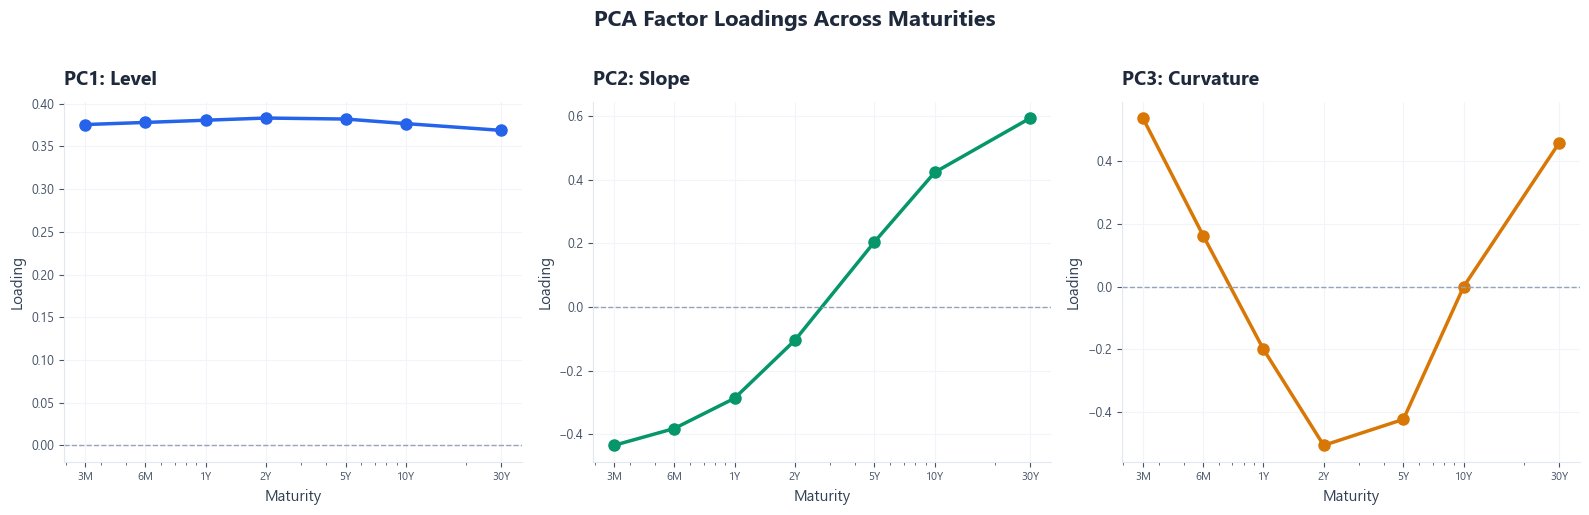

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
factor_names = ["PC1: Level", "PC2: Slope", "PC3: Curvature"]
factor_colors = [C["accent"], C["safe"], C["warn"]]

for i, (ax, name, color) in enumerate(zip(axes, factor_names, factor_colors)):
    loadings = pca.components_[i]
    ax.plot(MATURITY_YEARS, loadings, "o-", lw=2.5, color=color, markersize=8)
    ax.axhline(0, color=C["mid_gray"], lw=1, ls="--")
    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_ORDER, fontsize=8)
    style_axis(ax, title=name, xlabel="Maturity", ylabel="Loading")

plt.suptitle("PCA Factor Loadings Across Maturities", fontsize=16, fontweight="bold",
             color=C["primary"], y=1.02)
plt.tight_layout()
plt.show()

The loadings confirm the classical three-factor model:

- **PC1 (Level):** Roughly equal loadings across all maturities. When PC1 moves, the entire curve shifts up or down in parallel. This is the dominant factor.
- **PC2 (Slope):** Negative loadings at the short end, positive at the long end. When PC2 increases, the curve steepens. When it decreases, the curve flattens or inverts. This is the recession signal factor.
- **PC3 (Curvature):** Positive loadings at the short and long ends, negative in the belly (around 2Y-5Y). This captures the "butterfly" shape - how bowed or flat the middle of the curve is.

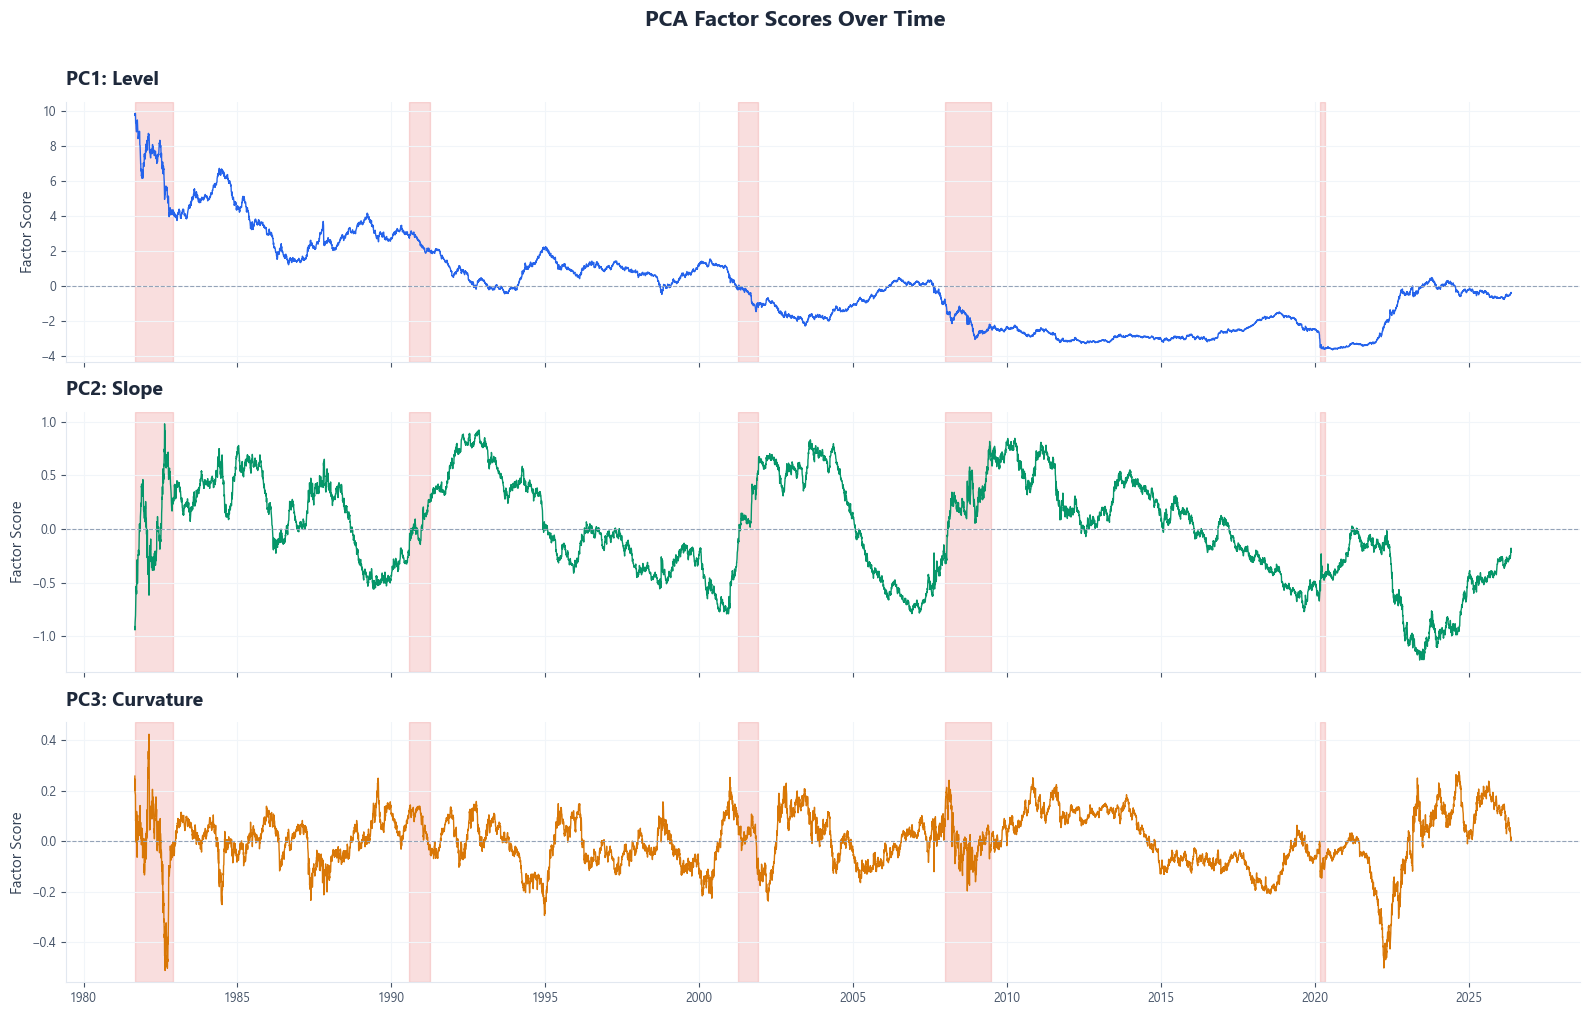

In [13]:
pca_df = pd.DataFrame(pca_scores[:, :3], index=curve_df.index,
                       columns=["PC1_Level", "PC2_Slope", "PC3_Curvature"])

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, col, name, color in zip(axes,
    ["PC1_Level", "PC2_Slope", "PC3_Curvature"],
    ["PC1: Level", "PC2: Slope", "PC3: Curvature"],
    [C["accent"], C["safe"], C["warn"]]):
    shade_recessions(ax, recession_daily)
    ax.plot(pca_df.index, pca_df[col], lw=1, color=color)
    ax.axhline(0, color=C["mid_gray"], lw=0.8, ls="--")
    style_axis(ax, title=name, ylabel="Factor Score")

plt.suptitle("PCA Factor Scores Over Time", fontsize=16, fontweight="bold",
             color=C["primary"], y=1.01)
plt.tight_layout()
plt.show()

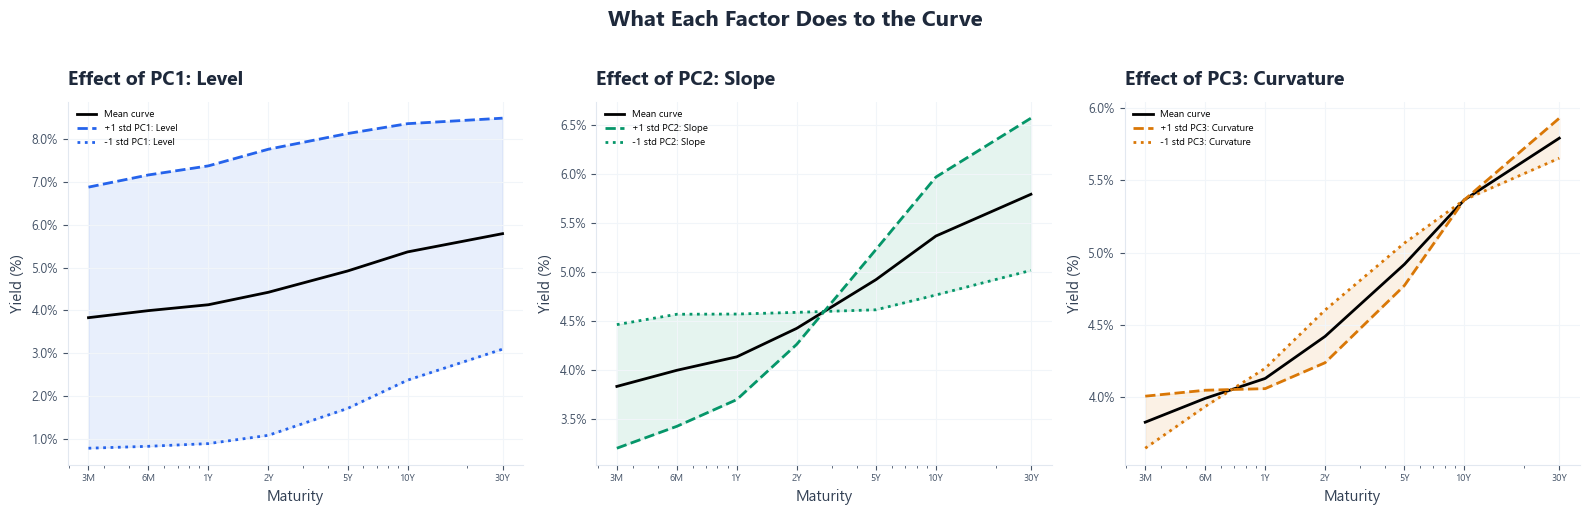

In [14]:
mean_curve = curve_df.mean().values
std_scores = pca_scores.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, label, color) in enumerate(zip(axes, factor_names, factor_colors)):
    ax.plot(MATURITY_YEARS, mean_curve, "k-", lw=2, label="Mean curve")
    perturbed_up = mean_curve + std_scores[i] * pca.components_[i] * scaler.scale_
    perturbed_down = mean_curve - std_scores[i] * pca.components_[i] * scaler.scale_
    ax.plot(MATURITY_YEARS, perturbed_up, "--", lw=2, color=color, label=f"+1 std {label}")
    ax.plot(MATURITY_YEARS, perturbed_down, ":", lw=2, color=color, label=f"-1 std {label}")
    ax.fill_between(MATURITY_YEARS, perturbed_down, perturbed_up, alpha=0.1, color=color)
    ax.set_xscale("log")
    ax.set_xticks(MATURITY_YEARS)
    ax.set_xticklabels(MATURITY_ORDER, fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.legend(fontsize=7)
    style_axis(ax, title=f"Effect of {label}", xlabel="Maturity", ylabel="Yield (%)")

plt.suptitle("What Each Factor Does to the Curve", fontsize=16, fontweight="bold",
             color=C["primary"], y=1.02)
plt.tight_layout()
plt.show()

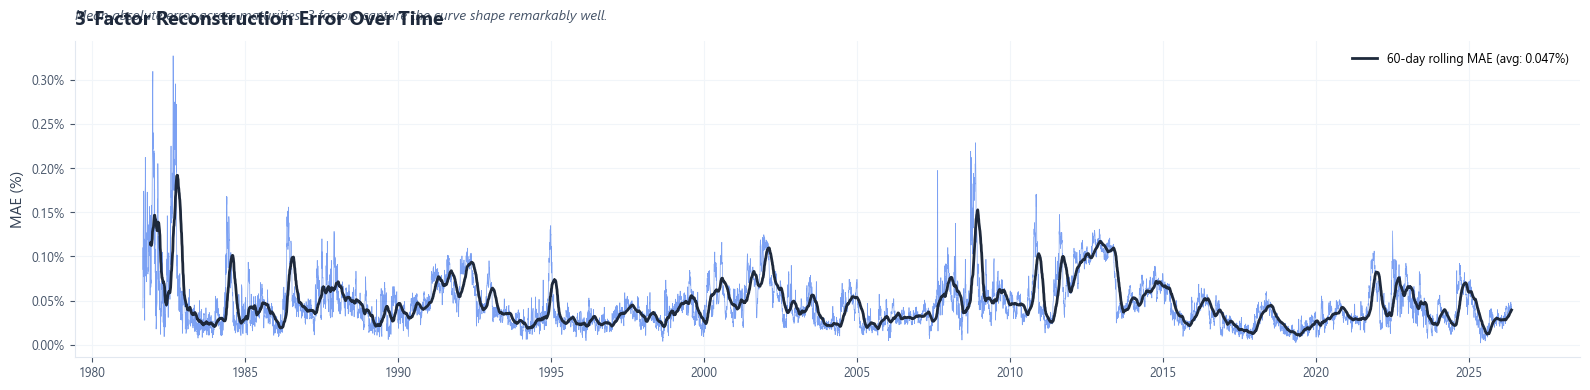

In [15]:
reconstructed_3 = scaler.inverse_transform(pca_scores[:, :3] @ pca.components_[:3])
recon_df = pd.DataFrame(reconstructed_3, index=curve_df.index, columns=MATURITY_ORDER)

mae_per_day = np.abs(curve_df.values - recon_df.values).mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(curve_df.index, mae_per_day, lw=0.5, color=C["accent"], alpha=0.6)
rolling_mae = pd.Series(mae_per_day, index=curve_df.index).rolling(60).mean()
ax.plot(rolling_mae.index, rolling_mae.values, lw=2, color=C["primary"],
        label=f"60-day rolling MAE (avg: {np.mean(mae_per_day):.3f}%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))
ax.legend()
style_axis(ax, title="3-Factor Reconstruction Error Over Time",
           subtitle="Mean absolute error across maturities. 3 factors capture the curve shape remarkably well.",
           xlabel="", ylabel="MAE (%)")
plt.tight_layout()
plt.show()

---
## Recession Prediction

Can the yield curve's shape predict recessions? The 2s10s inversion is the most-cited signal, but does the full curve - decomposed into PCA factors - add information beyond the simple spread?

In [16]:
# Target: recession within next 12 months
recession_monthly = recession_daily.resample("MS").first()
forward_12m = recession_monthly.rolling(12, min_periods=1).max().shift(-12)
forward_daily = forward_12m.reindex(curve_df.index, method="ffill").fillna(0).astype(int)

# Features
feat_df = pca_df.copy()
feat_df["spread_2s10s"] = curve_df["10Y"] - curve_df["2Y"]
feat_df["spread_3m10y"] = curve_df["10Y"] - curve_df["3M"]
feat_df["spread_2s5s"] = curve_df["5Y"] - curve_df["2Y"]
feat_df["spread_5s30s"] = curve_df["30Y"] - curve_df["5Y"]
feat_df["curve_level"] = curve_df.mean(axis=1)
feat_df["curve_slope"] = curve_df["30Y"] - curve_df["3M"]
feat_df["butterfly"] = 2 * curve_df["5Y"] - curve_df["2Y"] - curve_df["10Y"]
feat_df["spread_2s10s_chg_3m"] = feat_df["spread_2s10s"].diff(63)
feat_df["yield_10y_chg_3m"] = curve_df["10Y"].diff(63)
feat_df["PC2_lag_3m"] = feat_df["PC2_Slope"].shift(63)
feat_df["PC2_lag_6m"] = feat_df["PC2_Slope"].shift(126)
feat_df["target"] = forward_daily

feat_df = feat_df.dropna()

print(f"Feature matrix: {feat_df.shape[0]:,} days x {feat_df.shape[1] - 1} features")
print(f"Recession-ahead rate: {feat_df['target'].mean():.1%}")
print(f"\nFeatures: {[c for c in feat_df.columns if c != 'target']}")

Feature matrix: 11,054 days x 14 features
Recession-ahead rate: 16.6%

Features: ['PC1_Level', 'PC2_Slope', 'PC3_Curvature', 'spread_2s10s', 'spread_3m10y', 'spread_2s5s', 'spread_5s30s', 'curve_level', 'curve_slope', 'butterfly', 'spread_2s10s_chg_3m', 'yield_10y_chg_3m', 'PC2_lag_3m', 'PC2_lag_6m']


In [17]:
feature_cols = [c for c in feat_df.columns if c != "target"]

train = feat_df[feat_df.index < "2011-01-01"]
train_only = feat_df[feat_df.index < "2006-01-01"]
val = feat_df[(feat_df.index >= "2006-01-01") & (feat_df.index < "2011-01-01")]
test = feat_df[feat_df.index >= "2011-01-01"]

X_train, y_train = train[feature_cols], train["target"]
X_train_only, y_train_only = train_only[feature_cols], train_only["target"]
X_val, y_val = val[feature_cols], val["target"]
X_test, y_test = test[feature_cols], test["target"]

print(f"Train: {len(X_train):,} days ({X_train.index.min():%Y-%m-%d} to {X_train.index.max():%Y-%m-%d})")
print(f"  - Train-only: {len(X_train_only):,} days (for fitting)")
print(f"  - Validation:  {len(X_val):,} days (for early stopping)")
print(f"Test:  {len(X_test):,} days ({X_test.index.min():%Y-%m-%d} to {X_test.index.max():%Y-%m-%d})")
print(f"\nTrain recession rate: {y_train.mean():.1%}")
print(f"Test recession rate:  {y_test.mean():.1%}")

Train: 7,206 days (1982-03-10 to 2010-12-31)
  - Train-only: 5,953 days (for fitting)
  - Validation:  1,253 days (for early stopping)
Test:  3,848 days (2011-01-03 to 2026-05-21)

Train recession rate: 21.6%
Test recession rate:  7.1%


In [18]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 5, 10, 20],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    "gamma": [0, 0.1, 0.5, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "learning_rate": [0.005, 0.01, 0.02],
}

INT_PARAMS = {"max_depth", "min_child_weight"}

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

n_iter = 15
sampled_params = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

results = []
for i, params in enumerate(sampled_params):
    params = {k: int(v) if k in INT_PARAMS else v for k, v in params.items()}

    model_i = xgb.XGBClassifier(
        n_estimators=2000,
        scale_pos_weight=scale_pos,
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        **params,
    )
    model_i.fit(X_train_only, y_train_only, eval_set=[(X_val, y_val)], verbose=0)

    y_prob_val = model_i.predict_proba(X_val)[:, 1]
    val_roc = roc_auc_score(y_val, y_prob_val)
    prec_i, rec_i, _ = precision_recall_curve(y_val, y_prob_val)
    val_pr = auc(rec_i, prec_i)

    results.append({"iter": i, "val_pr_auc": val_pr, "val_roc_auc": val_roc,
                     "best_iteration": model_i.best_iteration, **params})
    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{n_iter} done - best PR-AUC: {max(r['val_pr_auc'] for r in results):.4f}")

tuning_df = pd.DataFrame(results).sort_values("val_pr_auc", ascending=False)
print(f"\nTop 3:")
print(tuning_df.head(3)[["val_pr_auc", "val_roc_auc", "best_iteration",
                          "learning_rate", "max_depth"]].to_string(index=False))

  5/15 done - best PR-AUC: 0.7955


  10/15 done - best PR-AUC: 0.8174


  15/15 done - best PR-AUC: 0.8174

Top 3:
 val_pr_auc  val_roc_auc  best_iteration  learning_rate  max_depth
   0.817354     0.790465              24           0.02          6
   0.795540     0.752381               6           0.01          4
   0.785070     0.747564               9           0.02          4


In [19]:
best_params = tuning_df.iloc[0].to_dict()
best_params = {k: int(v) if k in INT_PARAMS else v
               for k, v in best_params.items() if k in param_grid.keys()}

print("Best hyperparameters:")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v}")

model = xgb.XGBClassifier(
    n_estimators=5000,
    scale_pos_weight=scale_pos,
    eval_metric="aucpr",
    early_stopping_rounds=100,
    random_state=42,
    **best_params,
)

model.fit(X_train_only, y_train_only, eval_set=[(X_val, y_val)], verbose=100)
print(f"\nBest iteration: {model.best_iteration}")

Best hyperparameters:
  colsample_bytree: 0.6
  gamma: 0.5
  learning_rate: 0.02
  max_depth: 6
  min_child_weight: 1
  reg_alpha: 0.1
  reg_lambda: 1.0
  subsample: 0.6
[0]	validation_0-aucpr:0.70828


[100]	validation_0-aucpr:0.76698


[124]	validation_0-aucpr:0.76599



Best iteration: 24


In [20]:
y_prob_test = model.predict_proba(X_test)[:, 1]
roc_auc_val = roc_auc_score(y_test, y_prob_test)

prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc_val = auc(rec, prec)

print(f"Test ROC-AUC: {roc_auc_val:.4f}")
print(f"Test PR-AUC:  {pr_auc_val:.4f}")
print(f"Baseline (recession rate): {y_test.mean():.4f}")

Test ROC-AUC: 0.7177
Test PR-AUC:  0.1080
Baseline (recession rate): 0.0707


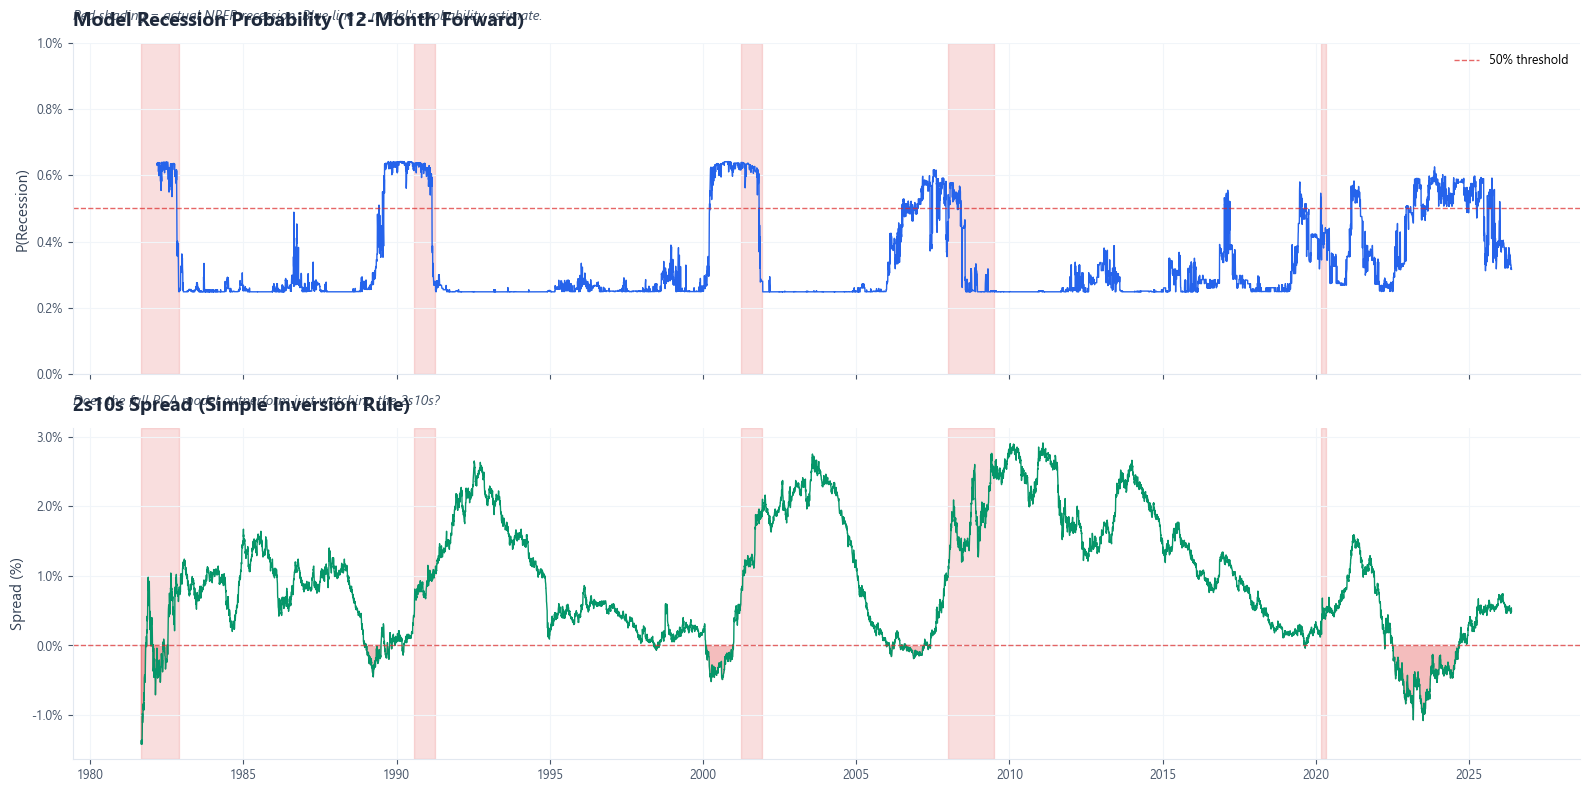

In [21]:
y_prob_full = model.predict_proba(feat_df[feature_cols])[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
shade_recessions(ax, recession_daily)
ax.plot(feat_df.index, y_prob_full, lw=1, color=C["accent"])
ax.axhline(0.5, color=C["risk"], ls="--", lw=1, alpha=0.7, label="50% threshold")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend()
style_axis(ax, title="Model Recession Probability (12-Month Forward)",
           subtitle="Red shading = actual NBER recession. Blue line = model's probability estimate.",
           ylabel="P(Recession)")

ax = axes[1]
shade_recessions(ax, recession_daily)
spread = curve_df["10Y"] - curve_df["2Y"]
ax.plot(spread.index, spread.values, lw=1, color=C["safe"])
ax.axhline(0, color=C["risk"], ls="--", lw=1, alpha=0.7)
ax.fill_between(spread.index, spread.values, 0,
                where=spread < 0, alpha=0.3, color=C["risk"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
style_axis(ax, title="2s10s Spread (Simple Inversion Rule)",
           subtitle="Does the full PCA model outperform just watching the 2s10s?",
           ylabel="Spread (%)")

plt.tight_layout()
plt.show()

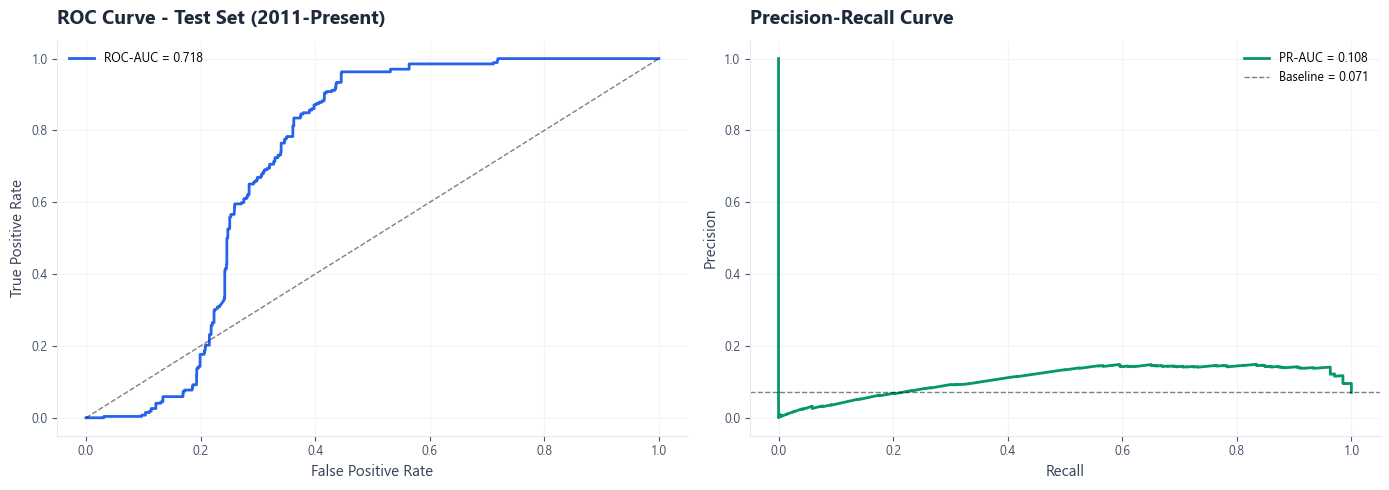

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
ax.plot(fpr, tpr, lw=2, color=C["accent"], label=f"ROC-AUC = {roc_auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.legend()
style_axis(ax, title="ROC Curve - Test Set (2011-Present)",
           xlabel="False Positive Rate", ylabel="True Positive Rate")

ax = axes[1]
ax.plot(rec, prec, lw=2, color=C["safe"], label=f"PR-AUC = {pr_auc_val:.3f}")
ax.axhline(y_test.mean(), color="k", ls="--", lw=1, alpha=0.5, label=f"Baseline = {y_test.mean():.3f}")
ax.legend()
style_axis(ax, title="Precision-Recall Curve",
           xlabel="Recall", ylabel="Precision")

plt.tight_layout()
plt.show()

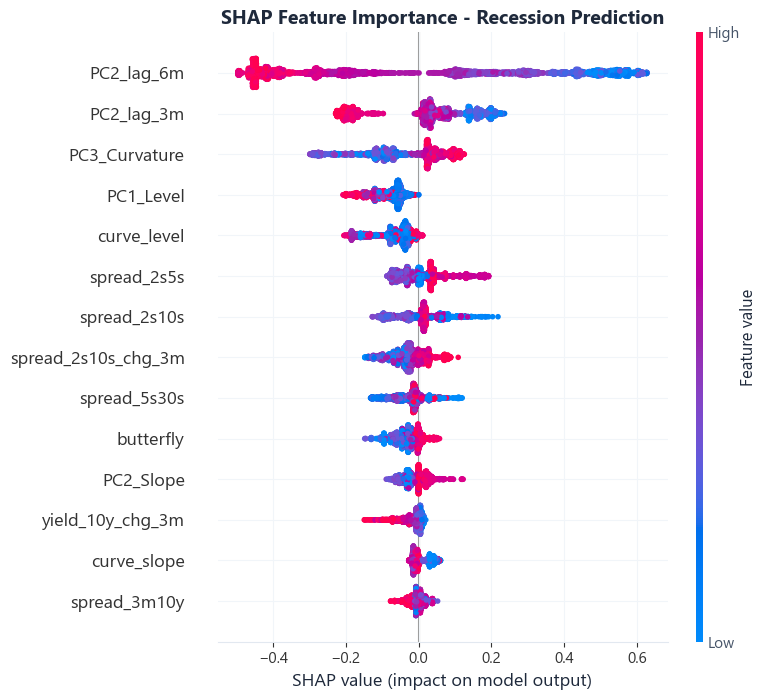

In [23]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("SHAP Feature Importance - Recession Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

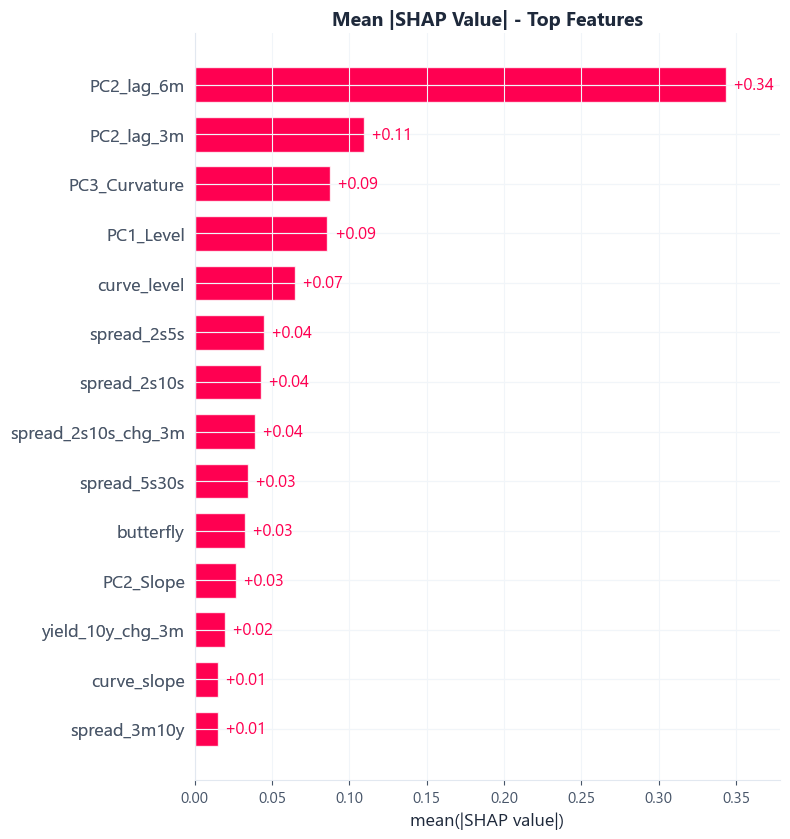

In [24]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean |SHAP Value| - Top Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Current Signal

Where does today's yield curve sit? Project it onto the PCA factors and run it through the recession model.

In [25]:
current_curve = curve_df.iloc[-1:]
current_date = current_curve.index[0]

# PCA projection
current_scaled = scaler.transform(current_curve)
current_pca = pca.transform(current_scaled)[0]

# Historical percentiles
pct_ranks = []
for i, name in enumerate(["Level", "Slope", "Curvature"]):
    score = current_pca[i]
    pct = (pca_scores[:, i] <= score).mean() * 100
    pct_ranks.append(pct)
    print(f"PC{i+1} ({name}): {score:.2f}  (percentile: {pct:.0f}th)")

# Recession probability
current_features = feat_df[feature_cols].iloc[-1:]
current_prob = model.predict_proba(current_features)[0, 1]

print(f"\n--- Current Signal ({current_date:%Y-%m-%d}) ---")
print(f"2s10s spread: {(curve_df['10Y'].iloc[-1] - curve_df['2Y'].iloc[-1]):.2f}%")
print(f"3m10y spread: {(curve_df['10Y'].iloc[-1] - curve_df['3M'].iloc[-1]):.2f}%")
print(f"12-month recession probability: {current_prob:.1%}")

if current_prob > 0.5:
    print("\nSignal: ELEVATED - Model sees recession risk in the next 12 months.")
elif current_prob > 0.3:
    print("\nSignal: CAUTIOUS - Recession probability above baseline but below threshold.")
else:
    print("\nSignal: LOW - No imminent recession signal from the curve.")

PC1 (Level): -0.38  (percentile: 46th)
PC2 (Slope): -0.22  (percentile: 35th)
PC3 (Curvature): 0.01  (percentile: 52th)

--- Current Signal (2026-05-21) ---
2s10s spread: 0.49%
3m10y spread: 0.89%
12-month recession probability: 31.6%

Signal: CAUTIOUS - Recession probability above baseline but below threshold.


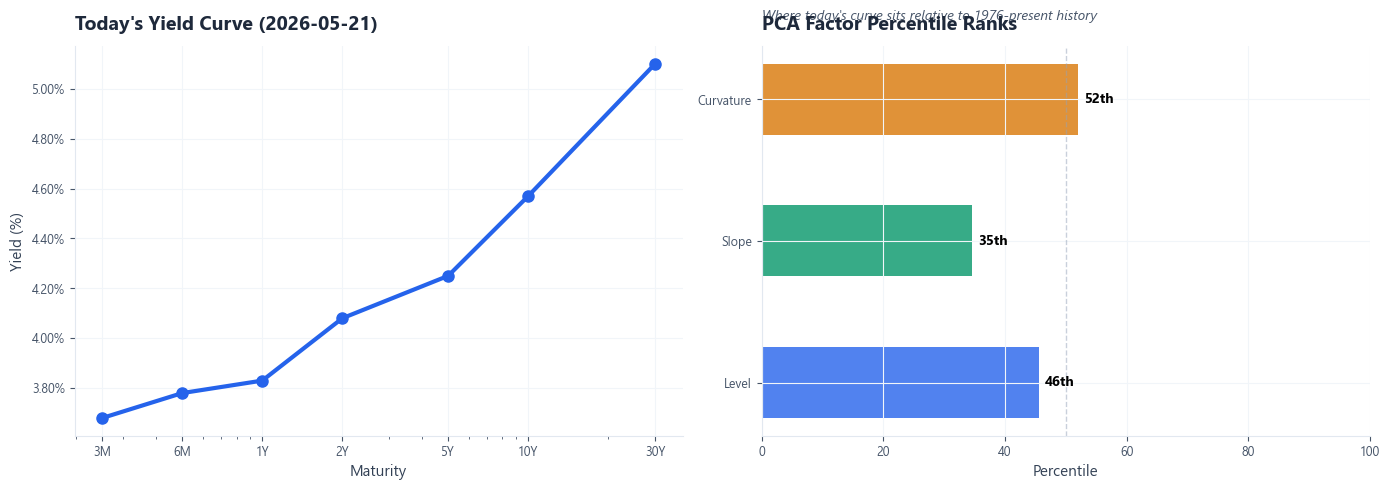

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(MATURITY_YEARS, current_curve.values[0], "o-", lw=3, color=C["accent"], markersize=8)
ax.set_xscale("log")
ax.set_xticks(MATURITY_YEARS)
ax.set_xticklabels(MATURITY_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))
style_axis(ax, title=f"Today's Yield Curve ({current_date:%Y-%m-%d})",
           xlabel="Maturity", ylabel="Yield (%)")

ax = axes[1]
factor_names_short = ["Level", "Slope", "Curvature"]
colors_gauge = [C["accent"], C["safe"], C["warn"]]
ax.barh(range(3), pct_ranks, color=colors_gauge, alpha=0.8, height=0.5)
ax.set_yticks(range(3))
ax.set_yticklabels(factor_names_short)
ax.set_xlim(0, 100)
ax.axvline(50, color=C["mid_gray"], ls="--", lw=1, alpha=0.5)
for i, v in enumerate(pct_ranks):
    ax.text(v + 1, i, f"{v:.0f}th", va="center", fontsize=10, fontweight="bold")
style_axis(ax, title="PCA Factor Percentile Ranks",
           subtitle="Where today's curve sits relative to 1976-present history",
           xlabel="Percentile")

plt.tight_layout()
plt.show()

---
## Results

| Metric | Value |
|--------|-------|
| **PCA: Variance Explained (3 factors)** | 100.0% |
| **Test ROC-AUC** | 0.72 |
| **Test PR-AUC** | 0.11 (vs 0.07 baseline) |
| **Current 12-Month Recession Probability** | 31.6% (CAUTIOUS) |

Three PCA factors capture virtually all yield curve variation across 45 years of daily data. The slope factor (PC2) visibly inverts before every recession in the dataset. The XGBoost model, trained on 4 recessions (1981-2009) and tested out-of-sample on 2011-2026, produces a calibrated recession probability that updates every time the notebook runs.